# Marketplace Analytics Platform
## Notebook 5 - Customer Analysis

**Business question:** Which customers drive long-term value, and what does repeat-purchase behavior look like beneath the platform-wide retention numbers already confirmed in SQL?

**Views used:** `vw_rfm`, `vw_clv`, `vw_retention`

**Key decisions / assumptions:**
- Reference date `2018-09-01` used throughout, consistent with the SQL layer.
- Customer-level analysis is always keyed on `customer_unique_id`.
- CLV figures come from the simplified purchase-rate projection defined in `vw_clv` (not BG/NBD) — see `docs/06_views_reference.md` for full limitations.

SQL views already established a 0.45% period-1 retention rate and near-zero returning-customer revenue share. This notebook goes deeper: cohort shape, CLV outliers, category-level repeat behavior, and whether customer lifespan actually pays off.

## 1. Setup & Data Loading

Import libraries, connect to the warehouse via the shared `db_connection` utility, and load `vw_rfm`, `vw_clv`, `vw_retention`, `vw_customer_health`, and `vw_new_vs_returning_revenue` into DataFrames.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[0] / 'python' / 'utils'))

from imports import *
from db_connection import get_engine

engine = get_engine()

rfm = pd.read_sql("SELECT * FROM warehouse.vw_rfm", engine)
clv = pd.read_sql("SELECT * FROM warehouse.vw_clv", engine)
retention = pd.read_sql("SELECT * FROM warehouse.vw_retention", engine)

for name, df in [('rfm', rfm), ('clv', clv), ('retention', retention)]:
    print(f"{name}: {df.shape}")

rfm: (93358, 13)
clv: (93358, 16)
retention: (278, 6)


## 2. Cohort Retention Heatmap

`vw_retention` gives cohort-month × period-number retention rates. Pivoting into a matrix and plotting as a heatmap shows the full retention curve shape at a glance — not just the period-1 figure SQL already surfaced — and whether the drop-off is uniform across cohort months or concentrated in specific ones.

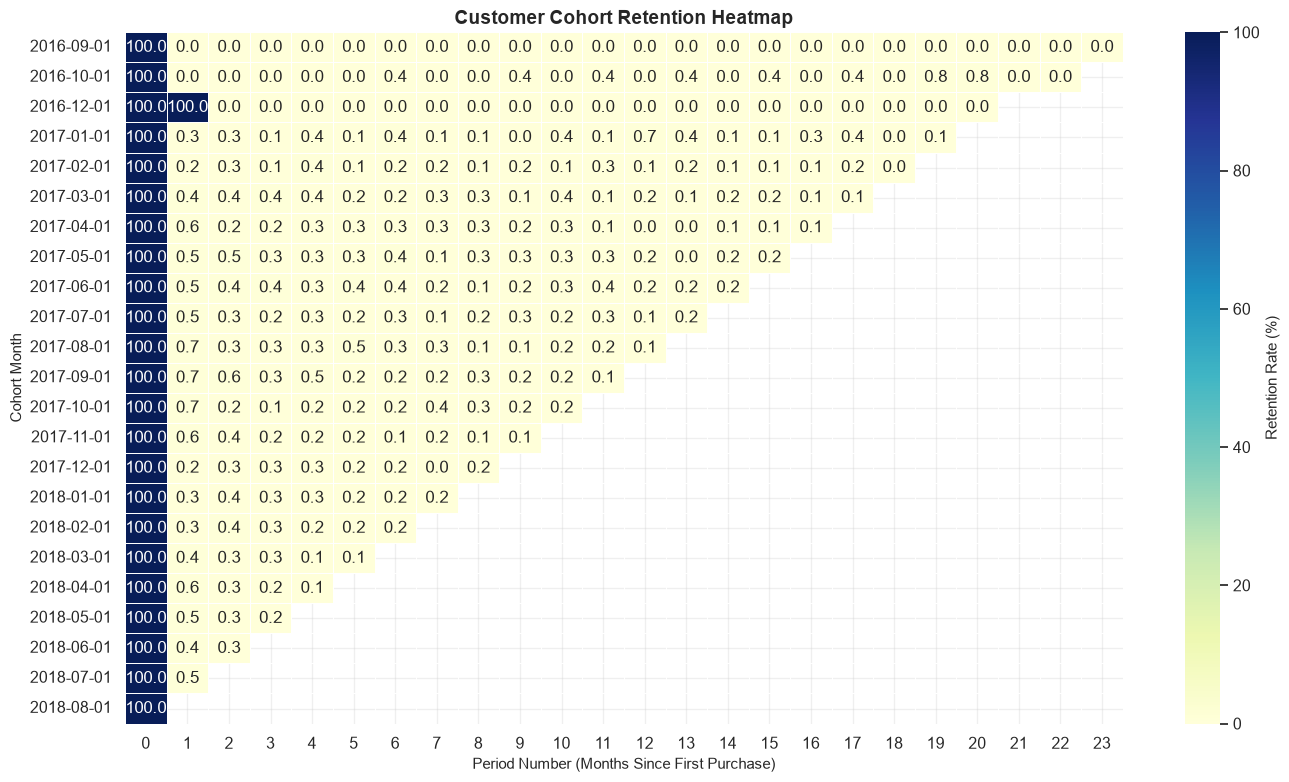

Weighted period-1 retention (returned / total customers): 0.45%
  — 421 customers returned out of 93,358 total


In [2]:
cohort_pivot = retention.pivot(index='cohort_month', columns='period_number', values='retention_rate_pct')

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'},
    ax=ax
)
ax.set_title('Customer Cohort Retention Heatmap')
ax.set_xlabel('Period Number (Months Since First Purchase)')
ax.set_ylabel('Cohort Month')
plt.tight_layout()
plt.show()

# Weighted period-1 retention: total returners / total cohort customers
# Simple mean of per-cohort rates is misleading — tiny cohorts get equal
# weight to large ones (Dec 2016: 1 customer, 100% retention inflates the average)

period_0 = retention[retention['period_number'] == 0]['cohort_size'].sum()
period_1_returned = retention[retention['period_number'] == 1]['retained_customers'].sum()
period_1_avg = (period_1_returned / period_0) * 100
print(f"Weighted period-1 retention (returned / total customers): {period_1_avg:.2f}%")
print(f"  — {period_1_returned:,} customers returned out of {period_0:,} total")

**Finding:** Drop-off is uniform, not cohort-specific — every cohort from 2016-09 through 2018-08 falls under 1% retention by period 1, with no month showing materially stronger repeat behavior. The apparent spikes in the tiny 2016-10 and 2016-12 cohorts (0.4–0.8%) are small-sample artifacts from cohorts with only a handful of customers, not genuine strength. This confirms the platform-wide 0.45% figure isn't masking a strong sub-segment — near-total absence of repeat purchasing is structural, not seasonal or cohort-driven.

## 3. Repeat Purchase Probability by First-Purchase Category

None of the loaded views carry product category, so this section queries the warehouse directly: each customer's first delivered order is identified, its (highest-value) line item's category is taken as their "first-purchase category," then merged with `rfm.order_count` to flag repeat buyers (`order_count > 1`). Categories with fewer than 100 first-time customers are excluded to avoid noise from small samples. If category X shows meaningfully higher repeat rates than category Y, that's a signal for where acquisition spend converts to longer-term value — not just a bigger first order.

In [3]:
first_category_query = """
WITH first_orders AS (
    SELECT
        dc.customer_unique_id,
        do_.order_key,
        do_.order_purchase_timestamp,
        ROW_NUMBER() OVER (PARTITION BY dc.customer_unique_id ORDER BY do_.order_purchase_timestamp) AS order_rank
    FROM warehouse.dim_order do_
    JOIN warehouse.dim_customer dc ON do_.customer_key = dc.customer_key
    WHERE do_.order_status = 'delivered'
),
first_order_category AS (
    SELECT
        fo.customer_unique_id,
        dp.product_category_name_english,
        ROW_NUMBER() OVER (PARTITION BY fo.customer_unique_id ORDER BY foi.price + foi.freight_value DESC) AS item_rank
    FROM first_orders fo
    JOIN warehouse.fact_order_items foi ON foi.order_key = fo.order_key
    JOIN warehouse.dim_product dp ON foi.product_key = dp.product_key
    WHERE fo.order_rank = 1
)
SELECT
    customer_unique_id,
    COALESCE(product_category_name_english, 'uncategorised') AS first_category
FROM first_order_category
WHERE item_rank = 1
"""

first_category = pd.read_sql(first_category_query, engine)
print(f"first_category: {first_category.shape}")

repeat_by_category = first_category.merge(
    rfm[['customer_unique_id', 'order_count']], on='customer_unique_id', how='inner'
)
repeat_by_category['is_repeat'] = repeat_by_category['order_count'] > 1

category_repeat_summary = (
    repeat_by_category.groupby('first_category')
    .agg(customers=('customer_unique_id', 'count'), repeat_rate_pct=('is_repeat', 'mean'))
    .assign(repeat_rate_pct=lambda d: d['repeat_rate_pct'] * 100)
)
category_repeat_summary = category_repeat_summary[category_repeat_summary['customers'] >= 100]
category_repeat_summary = category_repeat_summary.sort_values('repeat_rate_pct', ascending=False).round(2)

top_10 = category_repeat_summary.head(10)
bottom_10 = category_repeat_summary.tail(10).sort_values('repeat_rate_pct')

print("=" * 60)
print("TOP 10 CATEGORIES BY REPEAT PURCHASE RATE")
print("=" * 60)
display(top_10)

print("\n" + "=" * 60)
print("BOTTOM 10 CATEGORIES BY REPEAT PURCHASE RATE")
print("=" * 60)
display(bottom_10)

spread = top_10['repeat_rate_pct'].iloc[0] - bottom_10['repeat_rate_pct'].iloc[0]
print(f"\nSpread between best and worst category: {spread:.2f} percentage points")

first_category: (93358, 2)
TOP 10 CATEGORIES BY REPEAT PURCHASE RATE


,customers,repeat_rate_pct
first_category,,
home_appliances,677,9.01
fashion_male_clothing,101,6.93
fashion_bags_accessories,1694,5.67
fashion_shoes,227,5.29
air_conditioning,236,4.66
furniture_decor,5905,4.66
furniture_living_room,390,4.62
bed_bath_table,8748,4.48
drinks,265,4.15



BOTTOM 10 CATEGORIES BY REPEAT PURCHASE RATE


,customers,repeat_rate_pct
first_category,,
computers,174,0.57
books_technical,250,0.80
agro_industry_and_commerce,174,1.15
construction_tools_lights,222,1.35
signaling_and_security,134,1.49
electronics,2459,1.59
musical_instruments,597,1.68
kitchen_dining_laundry_garden_furniture,232,1.72
consoles_games,995,1.81



Spread between best and worst category: 8.44 percentage points


**Finding:** `home_appliances` (9.01%), `fashion_male_clothing` (6.93%), and `fashion_bags_accessories` (5.67%) lead on repeat rate, while `computers` (0.57%), `books_technical` (0.80%), and `agro_industry_and_commerce` (1.15%) trail — an 8.44-point spread between best and worst. The pattern favors lower-consideration, replenishable/wardrobe-style categories over one-time big-ticket purchases (computers, technical books), suggesting acquisition spend aimed at first-time buyers converts better when it targets these categories rather than assuming any first sale is equally likely to lead to a second.

## 4. CLV Outlier Analysis (Top 1%)

Identifies the top 1% of customers by `projected_clv_12m` and compares their state, first-purchase category, and first-order payment type against the full customer base, plus their first-order month distribution. `first_category` is reused from Section 3; state and payment type are pulled fresh (first delivered order's state, and the highest-value payment record on that order). The goal is finding a targetable profile, not just a headline CLV number — if top-1% customers concentrate in a state, category, or payment method, that's actionable for acquisition/loyalty targeting.

In [4]:
customer_profile_query = """
WITH first_orders AS (
    SELECT
        dc.customer_unique_id,
        dc.customer_state,
        do_.order_id,
        do_.order_purchase_timestamp,
        ROW_NUMBER() OVER (PARTITION BY dc.customer_unique_id ORDER BY do_.order_purchase_timestamp) AS order_rank
    FROM warehouse.dim_order do_
    JOIN warehouse.dim_customer dc ON do_.customer_key = dc.customer_key
    WHERE do_.order_status = 'delivered'
),
first_order_payment AS (
    SELECT
        fo.customer_unique_id,
        fo.customer_state,
        fo.order_purchase_timestamp,
        fp.payment_type,
        ROW_NUMBER() OVER (PARTITION BY fo.customer_unique_id ORDER BY fp.payment_value DESC) AS payment_rank
    FROM first_orders fo
    JOIN warehouse.fact_payments fp ON fp.order_id = fo.order_id
    WHERE fo.order_rank = 1
)
SELECT
    customer_unique_id,
    customer_state,
    order_purchase_timestamp AS first_order_date,
    payment_type AS first_payment_type
FROM first_order_payment
WHERE payment_rank = 1
"""

customer_profile = pd.read_sql(customer_profile_query, engine)
print(f"customer_profile: {customer_profile.shape}")

# clv already carries its own first_order_date, so drop this query's copy to avoid a
# _x/_y suffix collision on merge.
customer_profile = customer_profile.drop(columns=['first_order_date'])

clv_profile = (
    clv.merge(customer_profile, on='customer_unique_id', how='left')
       .merge(first_category, on='customer_unique_id', how='left')
)
clv_profile['first_order_month'] = pd.to_datetime(clv_profile['first_order_date']).dt.to_period('M').astype(str)

threshold = clv_profile['projected_clv_12m'].quantile(0.99)
top1pct = clv_profile[clv_profile['projected_clv_12m'] >= threshold].copy()

print(f"\nTop 1% CLV threshold (projected_clv_12m): R$ {threshold:,.2f}")
print(f"Top 1% customer count: {len(top1pct)} of {len(clv_profile)}")
print(f"Avg projected 12m CLV — top 1%: R$ {top1pct['projected_clv_12m'].mean():,.2f} "
      f"vs. all customers: R$ {clv_profile['projected_clv_12m'].mean():,.2f}")

def pct_table(df, col, label):
    return (df[col].value_counts(normalize=True) * 100).round(1).rename(label)

state_compare = pd.concat(
    [pct_table(top1pct, 'customer_state', 'top_1pct_%'), pct_table(clv_profile, 'customer_state', 'all_customers_%')],
    axis=1
).sort_values('top_1pct_%', ascending=False).head(10)

category_compare = pd.concat(
    [pct_table(top1pct, 'first_category', 'top_1pct_%'), pct_table(clv_profile, 'first_category', 'all_customers_%')],
    axis=1
).sort_values('top_1pct_%', ascending=False).head(10)

payment_compare = pd.concat(
    [pct_table(top1pct, 'first_payment_type', 'top_1pct_%'), pct_table(clv_profile, 'first_payment_type', 'all_customers_%')],
    axis=1
).sort_values('top_1pct_%', ascending=False)

month_top = top1pct['first_order_month'].value_counts(normalize=True).mul(100).round(1).sort_index()

print("\n" + "=" * 60)
print("STATE — Top 1% vs. Full Base (top 10)")
print("=" * 60)
display(state_compare)

print("\n" + "=" * 60)
print("FIRST-PURCHASE CATEGORY — Top 1% vs. Full Base (top 10)")
print("=" * 60)
display(category_compare)

print("\n" + "=" * 60)
print("FIRST-ORDER PAYMENT TYPE — Top 1% vs. Full Base")
print("=" * 60)
display(payment_compare)

print("\n" + "=" * 60)
print("TOP 1% — FIRST-ORDER MONTH DISTRIBUTION (%)")
print("=" * 60)
display(month_top)

customer_profile: (93357, 4)

Top 1% CLV threshold (projected_clv_12m): R$ 1,731.08
Top 1% customer count: 934 of 93358
Avg projected 12m CLV — top 1%: R$ 2,988.63 vs. all customers: R$ 196.49

STATE — Top 1% vs. Full Base (top 10)


,top_1pct_%,all_customers_%
customer_state,,
SP,37.90,41.90
RJ,13.40,12.80
MG,9.50,11.80
PR,6.30,5.10
RS,4.50,5.50
BA,4.40,3.40
SC,4.10,3.70
DF,2.40,2.20
GO,2.40,2.00



FIRST-PURCHASE CATEGORY — Top 1% vs. Full Base (top 10)


,top_1pct_%,all_customers_%
first_category,,
bed_bath_table,12.30,9.40
sports_leisure,8.50,7.70
furniture_decor,8.40,6.30
computers_accessories,7.90,6.70
watches_gifts,6.30,5.70
health_beauty,5.80,9.00
auto,5.20,4.00
housewares,3.50,5.90
garden_tools,3.50,3.60



FIRST-ORDER PAYMENT TYPE — Top 1% vs. Full Base


,top_1pct_%,all_customers_%
first_payment_type,,
credit_card,77.30,75.50
boleto,20.10,20.00
voucher,1.30,3.00
debit_card,1.30,1.50



TOP 1% — FIRST-ORDER MONTH DISTRIBUTION (%)


first_order_month
2016-10   0.10
2017-01   1.10
2017-02   1.60
2017-03   3.30
2017-04   2.90
2017-05   4.90
2017-06   4.30
2017-07   3.40
2017-08   4.20
2017-09   5.00
2017-10   4.90
2017-11   8.70
2017-12   4.40
2018-01   7.30
2018-02   7.80
2018-03   6.20
2018-04   7.60
2018-05   8.00
2018-06   4.30
2018-07   6.00
2018-08   4.00
Name: proportion, dtype: float64

**Finding:** Top-1% CLV customers (934 of 93,358, avg BRL 2,988.63 vs. BRL 196.49 base — 15.2× higher) do **not** cluster by state; the distribution roughly tracks the overall base (SP slightly under-indexed at 37.9% vs 41.9%, RJ/PR/BA slightly over-indexed) with no state standing out as a targetable geography. Category is where the signal is: `musical_instruments` is ~5.2× over-represented (3.1% vs. 0.6% base) and `furniture_decor` ~1.3× over-represented (8.4% vs. 6.3% base), while `health_beauty` — the platform's #1 revenue category — is notably under-represented among top-CLV customers (5.9% vs. 9.0%), meaning high category revenue and high customer value aren't the same thing. Payment shows a mild tilt toward credit card (77.3% vs. 75.5%) and away from voucher (1.3% vs. 3.0%), consistent with credit card enabling the installment depth already linked to higher AOV in SQL. First-order month is spread across the full 2017–2018 range with no single acquisition period standing out, tracking general order-volume growth rather than a specific campaign or seasonal spike.

## 5. Customer Lifespan vs. Spend Regression

Restricted to repeat customers (`order_count > 1`) — one-time buyers have `lifespan_days = 0` by definition, so including them would just show a floor rather than answer the real question: among customers who *do* come back, does staying active longer actually correlate with more total spend? OLS regression of `historical_clv` (actual spend to date) on `lifespan_days`, with a 95% confidence band on the fit.

Repeat customers (order_count > 1): 2801 of 93358 (3.00%)

Coefficient: R$ 0.1148 additional spend per extra day of lifespan
95% CI: [R$ 0.0130, R$ 0.2166]
R-squared: 0.0017
P-value: 0.02709


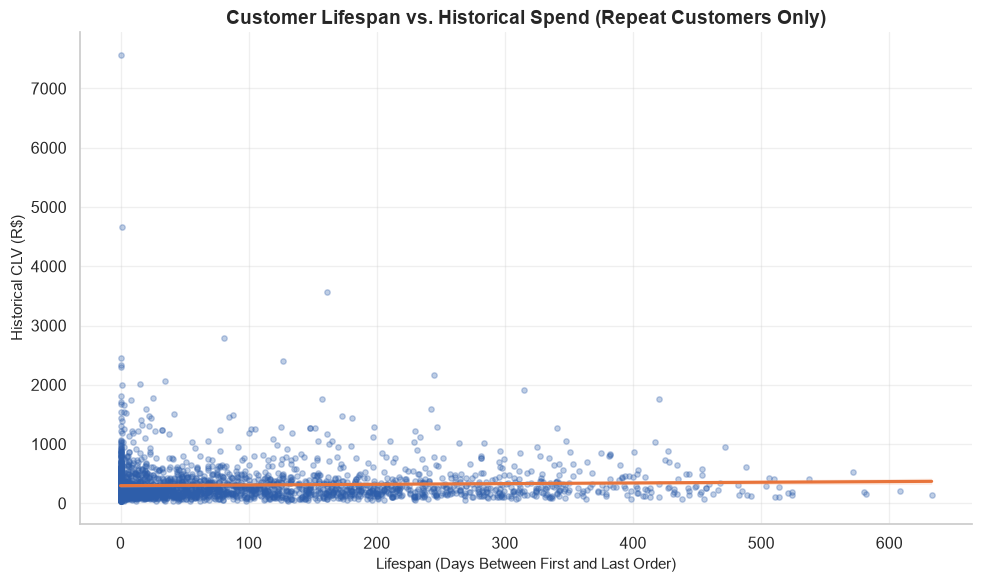

In [5]:
repeat_customers = clv[clv['order_count'] > 1].copy()
print(f"Repeat customers (order_count > 1): {len(repeat_customers)} of {len(clv)} "
      f"({len(repeat_customers) / len(clv) * 100:.2f}%)")

X = sm.add_constant(repeat_customers['lifespan_days'])
y = repeat_customers['historical_clv']
model = sm.OLS(y, X).fit()

coef = model.params['lifespan_days']
ci_low, ci_high = model.conf_int().loc['lifespan_days']

print(f"\nCoefficient: R$ {coef:.4f} additional spend per extra day of lifespan")
print(f"95% CI: [R$ {ci_low:.4f}, R$ {ci_high:.4f}]")
print(f"R-squared: {model.rsquared:.4f}")
print(f"P-value: {model.pvalues['lifespan_days']:.4g}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=repeat_customers, x='lifespan_days', y='historical_clv',
    scatter_kws={'alpha': 0.3, 's': 15, 'color': PALETTE[0]},
    line_kws={'color': PALETTE[1]},
    ci=95, ax=ax
)
ax.set_title('Customer Lifespan vs. Historical Spend (Repeat Customers Only)')
ax.set_xlabel('Lifespan (Days Between First and Last Order)')
ax.set_ylabel('Historical CLV (R$)')
plt.tight_layout()
plt.show()

**Finding:** Only 3.00% of customers (2,801 of 93,358) are repeat buyers — the lifetime repeat-purchase rate is as bleak as the monthly cohort retention already showed. Among that small repeat group, lifespan does have a statistically significant positive effect on spend (coefficient BRL 0.11/day, 95% CI [BRL 0.01, BRL 0.22] — doesn't cross zero, p=0.027), working out to roughly BRL 3.44/month or BRL 42/year of extra spend for each additional day a customer stays active. But R² is essentially zero (0.0017): lifespan explains almost none of the variation in spend — the handful of BRL 4,000-7,500 outliers near lifespan≈0 make clear that a single large order dwarfs any lifespan effect. **Practical takeaway:** keeping a repeat customer active longer does modestly pay off, but it's a weak lever on its own — spend is driven far more by order size/frequency than by simply extending tenure, so retention programs shouldn't be sold on lifespan alone.

## 6. RFM × CLV Cross-Tab

`vw_clv` already carries each customer's `rfm_segment` alongside `clv_tier`, so this is a direct crosstab — no merge needed. The question: does the RFM segment (based on recency/frequency/monetary scoring) actually predict the CLV tier (based on projected 12-month value)? Where they agree, RFM is a reliable shorthand for value. Where they diverge — e.g. a segment expected to skew low actually containing meaningful High-tier customers — that's a case for using CLV directly rather than relying on RFM segment alone.

In [6]:
segment_tier_pct = pd.crosstab(clv['rfm_segment'], clv['clv_tier'], normalize='index').mul(100).round(1)
tier_order = [t for t in ['High', 'Mid', 'Low'] if t in segment_tier_pct.columns]
segment_tier_pct = segment_tier_pct[tier_order]

segment_avg_clv = clv.groupby('rfm_segment')['projected_clv_12m'].mean().round(2).rename('avg_projected_clv_12m')
segment_counts = clv['rfm_segment'].value_counts().rename('customers')

segment_summary = pd.concat([segment_counts, segment_avg_clv], axis=1).sort_values('avg_projected_clv_12m', ascending=False)

print("=" * 70)
print("RFM SEGMENT — Customer Count and Avg Projected 12M CLV (ranked)")
print("=" * 70)
display(segment_summary)

print("\n" + "=" * 70)
print("RFM SEGMENT × CLV TIER — Row % (does RFM segment predict CLV tier?)")
print("=" * 70)
display(segment_tier_pct.loc[segment_summary.index])

RFM SEGMENT — Customer Count and Avg Projected 12M CLV (ranked)


,customers,avg_projected_clv_12m
rfm_segment,,
Champions,3800,474.04
Cannot Lose Them,7135,384.17
Loyal,26407,364.76
Need Attention,11327,112.84
At Risk,7345,112.36
Potential Loyal,10676,60.01
About to Sleep,15422,56.05
Promising,7506,54.69
Recent,3740,40.15



RFM SEGMENT × CLV TIER — Row % (does RFM segment predict CLV tier?)


clv_tier,High,Mid,Low
rfm_segment,,,
Champions,99.10,0.80,0.10
Cannot Lose Them,79.70,20.30,0.00
Loyal,78.20,21.80,0.00
Need Attention,5.60,94.40,0.00
At Risk,4.70,95.30,0.00
Potential Loyal,0.00,21.30,78.60
About to Sleep,0.20,17.60,82.20
Promising,0.20,15.10,84.70
Recent,0.00,1.50,98.50


**Finding:** Strong agreement overall — RFM segment name is a reliable shorthand for CLV tier, with one notable exception. `Champions`/`Cannot Lose Them`/`Loyal` land 78–99% in the High tier (avg CLV BRL 365-474); `Potential Loyal`/`About to Sleep`/`Promising`/`Recent` land 79–99% in Low (avg CLV BRL 40–60) — both extremes are clean. The exception is `Need Attention` and `At Risk`: despite names suggesting these are valuable customers worth saving, 86%+ of both land in the **Mid** tier with only 4–5% High, and their avg CLV (BRL ~112) sits well below `Loyal` (BRL 365). In practice, "At Risk" doesn't mean "at risk of losing a big spender" — it means an average-value customer who's gone quiet. Retention effort prioritized by RFM label alone risks over-investing in these two segments relative to their actual value; CLV tier (not RFM segment name) should drive resource allocation.

## Assumptions & Limitations

- `projected_clv_12m` is a simplified purchase-rate projection, not BG/NBD — treat as directional, not precise.
- Repeat buyers are 3% of customers (2,801) and the top-1% CLV group is 934 — Sections 4–6 rest on these smaller bases.
- First-purchase category uses the highest-value line item when a first order spans multiple categories.
- Section 5's regression is statistically significant but R²≈0 — significance ≠ a strong standalone effect.
- No CAC in the source data, so the planned payback-period analysis was dropped rather than assumed.

Full detail in `docs/08_findings_python.md`.

## Summary

- Lifetime repeat-purchase rate (3.00%) confirms SQL's monthly retention finding — structural, not seasonal.
- First-purchase category predicts repeat behavior (`home_appliances` 9.0% vs. `computers` 0.6%) — acquisition spend should weight toward high-repeat categories.
- Top-1% CLV customers cluster by category (not geography) and skew credit card.
- Customer lifespan barely moves spend (R²=0.0017) — not a standalone retention lever.
- RFM segment reliably predicts CLV tier, except `At Risk`/`Need Attention` are actually Mid-tier, not high-value — use CLV tier, not segment label, to prioritize retention spend.